In [9]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

In [10]:
df=pd.read_csv(r'..\..\Data\clean_pernoctaciones_07_04_2026.csv')

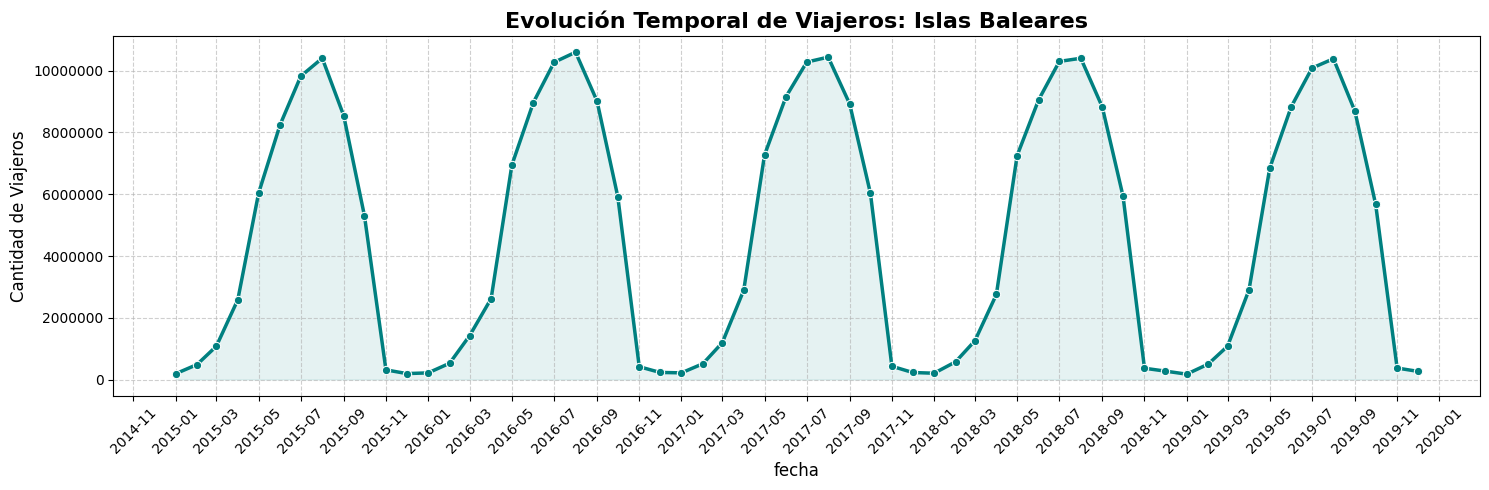

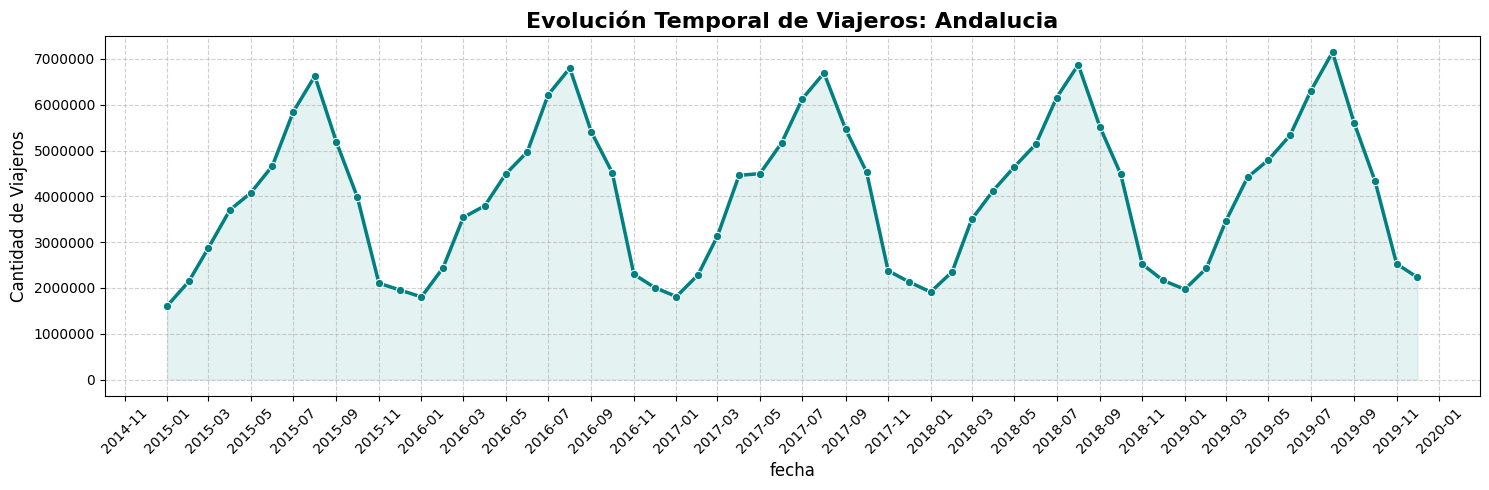

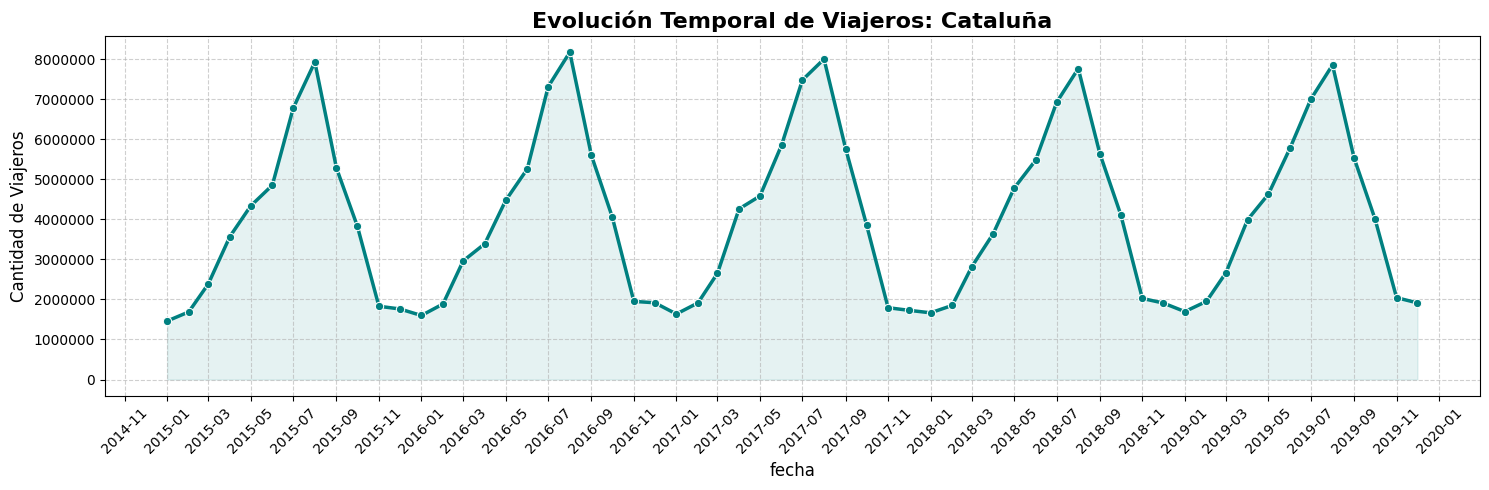

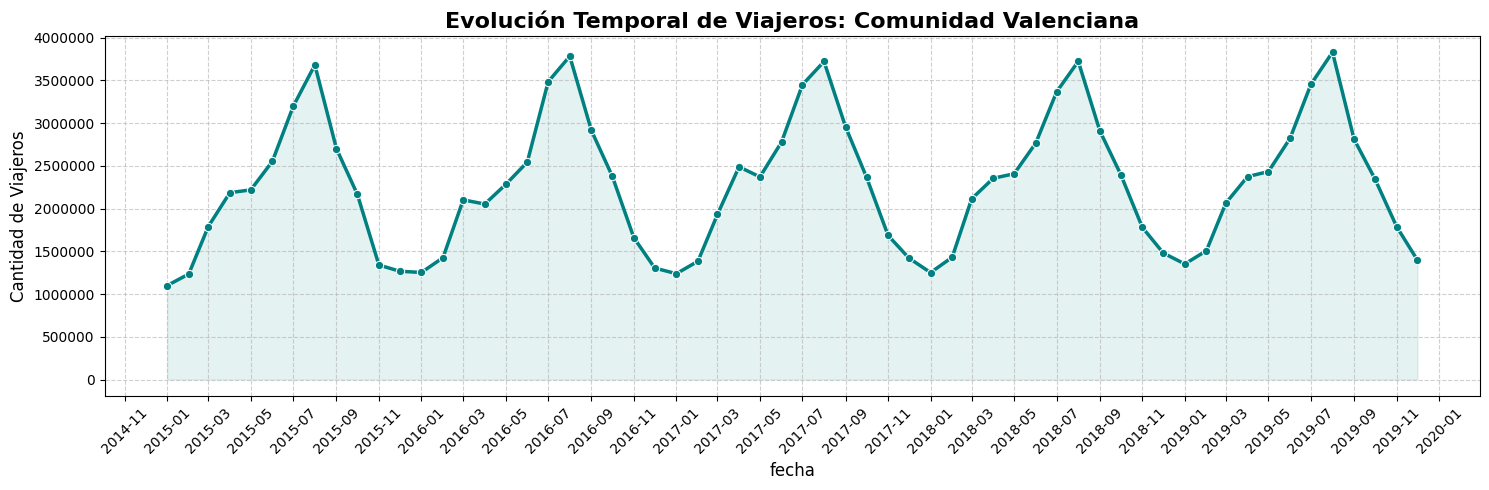

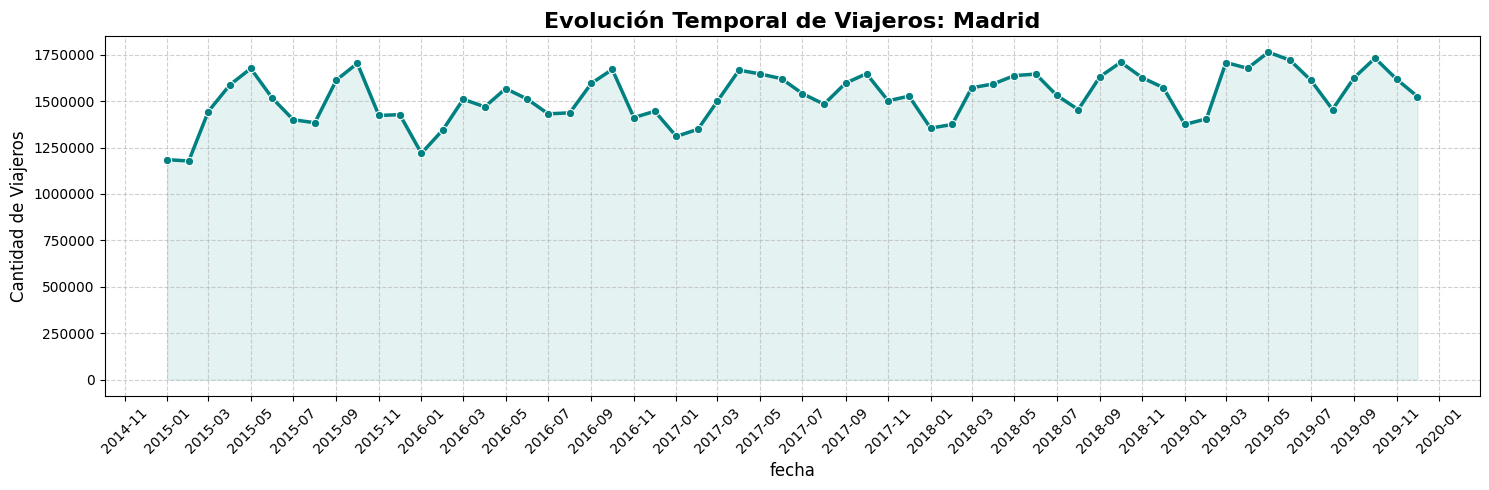

In [11]:
# 1. Preparar la fecha real para que el eje X sea ordenado y fluido
meses_dict = {'Enero':1, 'Febrero':2, 'Marzo':3, 'Abril':4, 'Mayo':5, 'Junio':6,
              'Julio':7, 'Agosto':8, 'Septiembre':9, 'Octubre':10, 'Noviembre':11, 'Diciembre':12}
df['mes_num'] = df['mes'].map(meses_dict)
df['fecha'] = pd.to_datetime(df['año'].astype(str) + '-' + df['mes_num'].astype(str) + '-01')

# 2. Agrupar para sumar viajeros de todos los países por CCAA y fecha
df_evol = df.groupby(['ccaa', 'fecha'])['qty_pernoctaciones'].sum().reset_index()

# 3. Lista de las CCAA que quieres analizar (puedes elegir las 5 principales)
lista_ccaa = df_evol.groupby('ccaa')['qty_pernoctaciones'].sum().nlargest(5).index

# 4. Generar los 5 gráficos individuales
for comunidad in lista_ccaa:
    plt.figure(figsize=(15, 5))
    data_plot = df_evol[df_evol['ccaa'] == comunidad]
    
    ax =sns.lineplot(data=data_plot, x='fecha', y='qty_pernoctaciones', color='teal', linewidth=2.5, marker='o')
    
    # Añadir sombreado para resaltar la estacionalidad (opcional pero muy visual)
    plt.fill_between(data_plot['fecha'], data_plot['qty_pernoctaciones'], color='teal', alpha=0.1)

    # A. Quitar notación científica del eje Y
    plt.ticklabel_format(style='plain', axis='y')
    
    # B. Formatear fechas del eje X (Año-Mes)
    # ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2)) 
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    # Opcional: rotar las fechas para que no se amontonen
    plt.xticks(rotation=45)
    
    plt.title(f'Evolución Temporal de Viajeros: {comunidad}', fontsize=16, fontweight='bold')
    plt.xlabel('fecha', fontsize=12)
    plt.ylabel('Cantidad de Viajeros', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

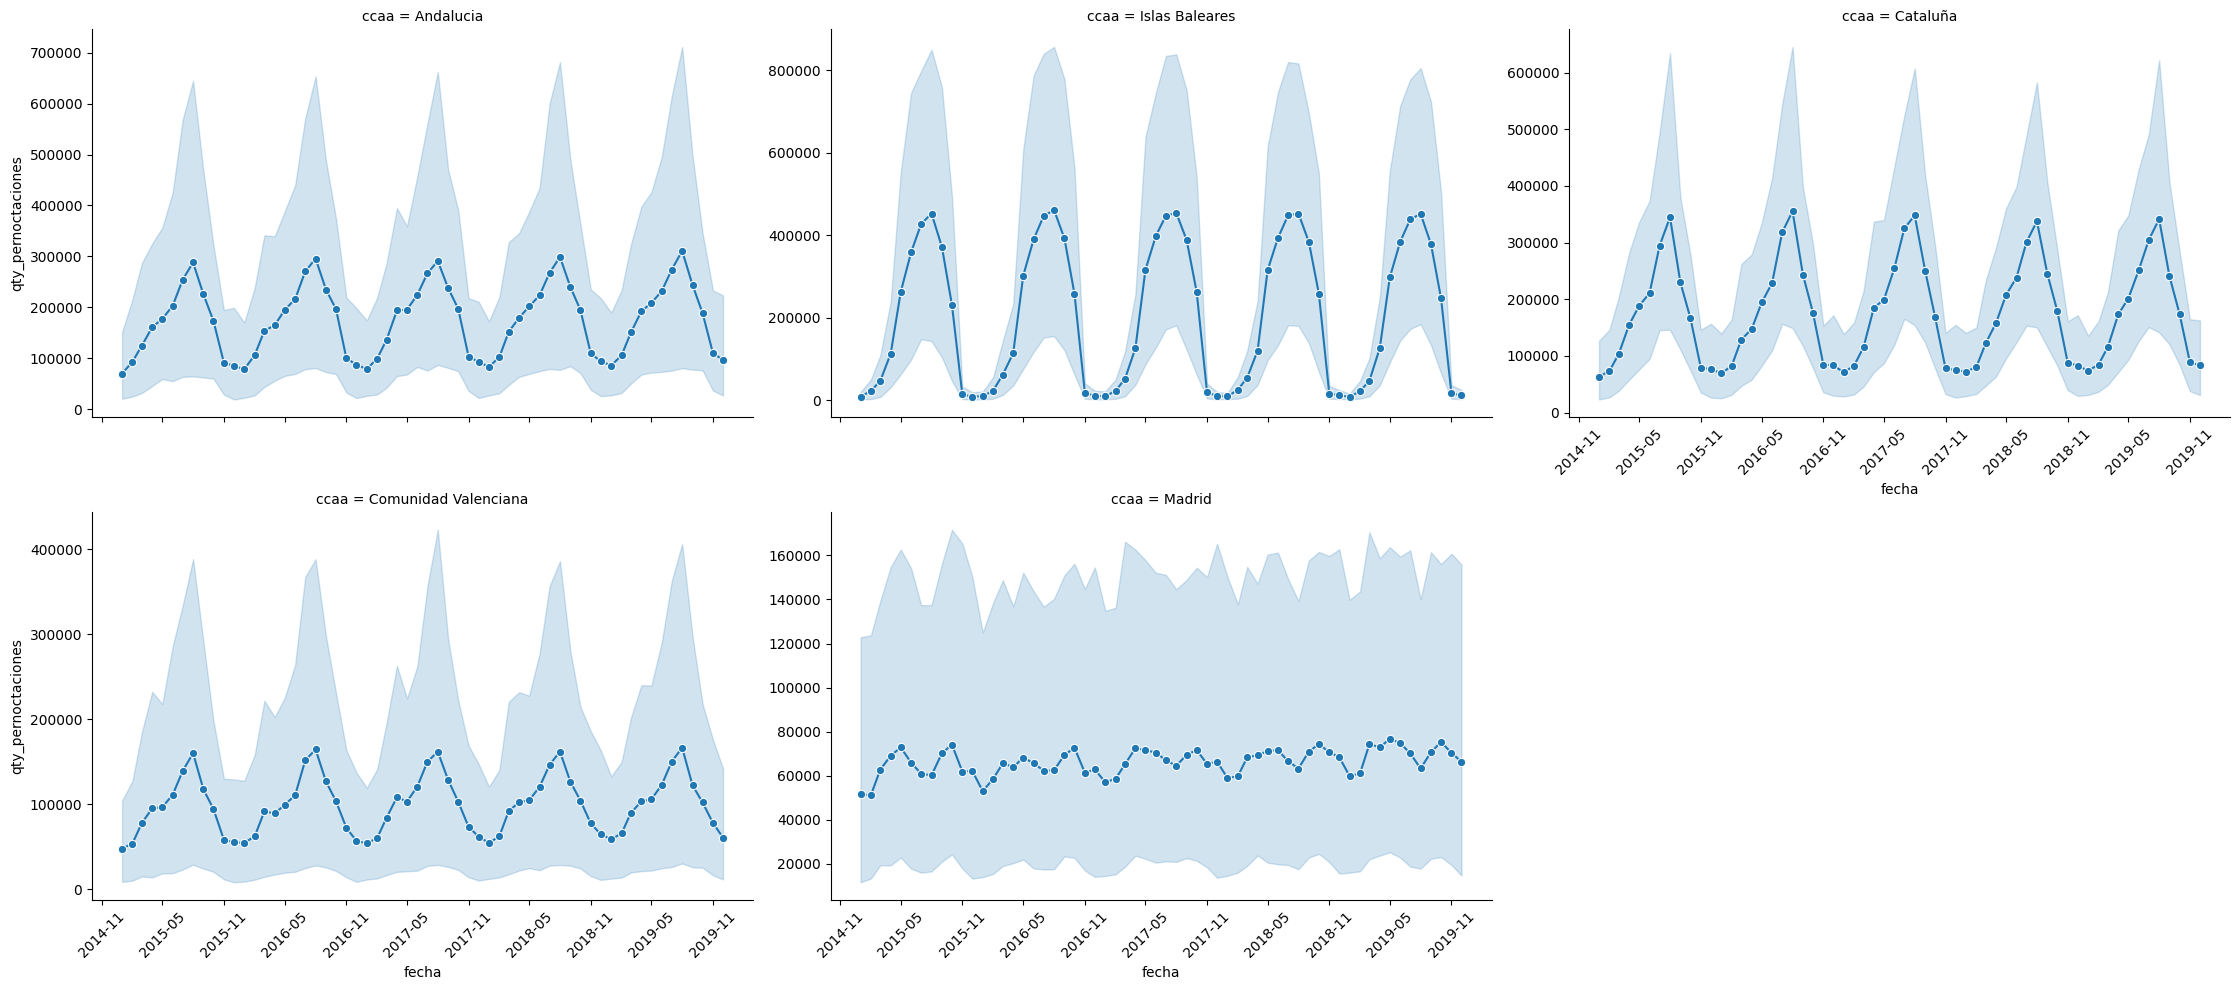

In [12]:
# 1. Crear el FacetGrid
g = sns.FacetGrid(df, col="ccaa", col_wrap=3, height=5, aspect=1.5, sharey=False)
g.map(sns.lineplot, "fecha", "qty_pernoctaciones", marker="o")

# 2. Configurar cada eje (ax) individualmente
for ax in g.axes.flat:
    # Quitar notación científica en el eje Y
    ax.ticklabel_format(style='plain', axis='y')
    
    # Configurar el intervalo de meses (ejemplo: cada 6 meses para que no sature)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6)) 
    
    # Formato de la etiqueta: Año-Mes
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    
    # Rotar las etiquetas para que sean legibles
    plt.setp(ax.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()